# Import Required libraries

In [2]:
# Import basic packages
import os
import warnings
warnings.filterwarnings("ignore")
import datetime
import re
from IPython.display import display, Markdown

# Basic ds packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from tqdm import tqdm

# decorator packages
from typing import List, Dict
import warnings
warnings.filterwarnings("ignore")

#sklearn packages
from sklearn.base import BaseEstimator, TransformerMixin

# Tensorflow packages
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.layers import (Dense,
                                    Layer,
                                    BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, 
                                        ModelCheckpoint)
from tensorflow.keras.optimizers import (Adam, 
                                         AdamW, 
                                         RMSprop)
from tensorflow.keras.losses import (SparseCategoricalCrossentropy,
                                     CategoricalCrossentropy)


# Tensorflow Text Packages
import nltk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS
from tensorflow.keras.preprocessing.text import Tokenizer


# Load Amazon Reviews Dataset

In [3]:
amazon_review_data = pd.read_csv("/Users/kavisanthoshkumar/Downloads/train.csv", header = None)
amazon_review_data.columns = ["polarity", "title", "text"]
amazon_review_data.head()

,polarity,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [4]:
print(f"Number of Reviews : {amazon_review_data.shape[0]}")
# We have 3.6M reviews

Number of Reviews : 3600000


#### 1. WordCloud Visualization



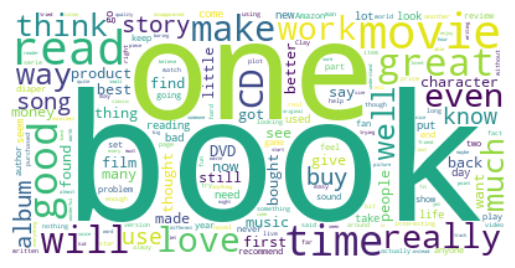

In [5]:
sentence_corpus = amazon_review_data["text"].to_list()
text = " ".join(sent for sent in sentence_corpus[:20000])

# eliminating stopwords while visualizing 
stopwords = set(STOPWORDS)

# Generating wordcloud image 
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)

# Displaying the generated image
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

#### 3. Preprocessing 


- Involves cleaning the text data by removing special characters, converting to lowercase, converting to base form, and removing stop words.

#### Step 1: LowerCase, Removing Stop Words

In [6]:
# First convert sentence_corpus into tensorflow datasets
tf_sentence_corpus = tf.constant(sentence_corpus)
tf_sentence_corpus = tf.data.Dataset.from_tensor_slices(tf_sentence_corpus)


def tokenize_fn(text):

    # converting into lowercase
    text = tf.strings.lower(text)

    # white space tokenization
    white_space_tokens = tf.expand_dims(tf.strings.split(text, sep = " "), axis = 0)

    # remove stopwords from the text
    tf_stop_words = tf.expand_dims(tf.constant(list(STOPWORDS)), axis=0)

    # While performing set difference make sure there dimensions of shape[0] is same 
    tokens = tf.sets.difference(white_space_tokens, tf_stop_words)

    return tokens.values


# Map tokenize_fin to tensorflow dataset
tf_sentence_corpus = tf_sentence_corpus.map(tokenize_fn, num_parallel_calls=tf.data.AUTOTUNE)

2025-07-10 15:57:54.059016: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-07-10 15:57:54.059066: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-07-10 15:57:54.059072: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
I0000 00:00:1752181074.059337   50988 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1752181074.059505   50988 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


#### Step 2: Lemmatization/PorterStemmer

In [ ]:
cleaned_corpus = list(tfds.as_numpy(tf_sentence_corpus))

In [ ]:
class lemmaStemmer:
    """
        Class : Perform lemmatization of PorterStemmer 
        Args:
           BaseWordForm[str]: By default this argument is set as lemmatization, and other option is PortStemmer approach 
    """
    def __init__(self, BaseWordForm = "lemma"):
        self.BaseWordForm = BaseWordForm

        # Initialize WordNetLemmatizer and PortStemmer
        self.lemma = WordNetLemmatizer()
        self.portstemmer = PorterStemmer()

    def __call__(self, text_numpy):

        result_numpy = np.array([])
        if self.BaseWordForm == "lemma":
            for word in text_numpy:
                # Decord Word - UTF-8
                decoded_word = word.decode("utf-8")
                
                # Remove Special Characters
                decoded_word = re.sub(r'[^\w\s]', '', decoded_word)
                
                # Append lemmatized word to numpy 
                result_numpy = np.append(result_numpy, self.lemma.lemmatize(decoded_word))
                
        else:
            for word in text_numpy:
                # Decord Word - UTF-8
                decoded_word = word.decode("utf-8")

                # Remove Special Characters
                decoded_word = re.sub(r'[^\w\s]', '', decoded_word)
                
                # Append lemmatized word to numpy 
                result_numpy = np.append(result_numpy,self.portstemmer.stem(decoded_word))

        return result_numpy

word_transformation = lemmaStemmer(BaseWordForm="lemma")

NameError: name 'WordNetLemmatizer' is not defined

In [ ]:
lemma_corpus = {}
for word_array, record_int in tqdm(zip(cleaned_corpus, range(0, len(cleaned_corpus)))):
    lemma_corpus[record_int] = word_transformation(word_array)

129673it [00:11, 11280.71it/s]Exception ignored in: <function tqdm.__del__ at 0x16c797550>
Traceback (most recent call last):
  File "/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/tqdm/notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
3600000it [06:17, 9533.38it/s] 


#### Step 3: getVocabulary

In [ ]:
lemma_corpus.values